# J. CIFAR-10 이미지 분류 GPU 가속 학습

앞에서는 MNIST 데이터셋을 사용하여 흑백 손글씨 숫자를 분류하는 CNN 모델을 구현했습니다.

이번 실습에서는 CIFAR-10 데이터셋을 사용하여 비행기, 자동차, 새, 고양이 등 실제 사물 이미지를 분류합니다.

CIFAR-10은 MNIST보다 이미지의 구조와 배경이 복잡하며, RGB 컬러 이미지로 구성되어 있어 분류 난이도가 더 높습니다.

## $1)$ 필수 라이브러리 import

필수 라이브러리는 MNIST 실습과 동일합니다.

In [2]:
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    # 모델을 학습 모드(training mode)로 변경
    model.train()

    # 결과를 누적하기 위한 변수
    total_loss = 0.0
    correct_count = 0
    sample_count = 0

    # 학습 데이터를 DataLoader(train_loader)의 Batch 단위로 불러와 학습 반복
    for images, labels in data_loader:
        # 장치(CPU/GPU)로 이동
        images = images.to(device)
        labels = labels.to(device)

        # Gradient 초기화 (이전 Batch에서 계산한 Gradient를 제거)
        optimizer.zero_grad()

        # 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
        logits = model(images)

        # Loss 계산
        loss = criterion(logits, labels)
        # 역전파를 통한 Gradient 계산
        loss.backward()
        # Gradient를 사용하여 파라미터 수정
        optimizer.step()

        # Batch 한 개의 이미지 개수
        batch_size = images.size(0)

        # 결과 누적
        total_loss += loss.item() * batch_size                 # Loss 누적 (1개 batch의 평균 loss x batch 크기)
        predictions = logits.argmax(dim=1)                     # 가장 높은 점수를 가진 클래스를 선택
        correct_count += (predictions == labels).sum().item()  # 정답을 맞춘 개수 계산
        sample_count += batch_size                             # 전체 샘플 수 누적

    # 평균 Loss 및 Accuracy 계산
    average_loss = total_loss / sample_count
    accuracy = correct_count / sample_count

    return average_loss, accuracy


def evaluate(model, data_loader, criterion, device):
    # 모델을 평가 모드(evaluation mode)로 변경
    model.eval()

    # 결과를 누적하기 위한 변수
    total_loss = 0.0
    correct_count = 0
    sample_count = 0

    # Gradient 계산을 비활성화 (파라미터 수정 비활성화)
    with torch.no_grad():
        # 평가 데이터를 DataLoader(test_loader)의 Batch 단위로 불러와 평가 반복
        for images, labels in data_loader:
            # 장치(CPU/GPU)로 이동
            images = images.to(device)
            labels = labels.to(device)

            # 학습된 모델의 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
            logits = model(images)

            # Loss 계산 (역전파는 수행하지 않음)
            loss = criterion(logits, labels)

            # Batch 한 개의 이미지 개수
            batch_size = images.size(0)

            # 결과 누적
            total_loss += loss.item() * batch_size                 # Loss 누적 (1개 batch의 평균 loss x batch 크기)
            predictions = logits.argmax(dim=1)                     # 가장 높은 점수를 가진 클래스를 선택
            correct_count += (predictions == labels).sum().item()  # 정답을 맞춘 개수 계산
            sample_count += batch_size                             # 전체 샘플 수 누적

        # 평균 Loss 및 Accuracy 계산
        average_loss = total_loss / sample_count
        accuracy = correct_count / sample_count

        return average_loss, accuracy

In [4]:
# SEED = 42
# DATA_ROOT = "src/datasets"

# BATCH_SIZE = 64
# TEST_BATCH_SIZE = 1000
# EPOCHS = 3
# LEARNING_RATE = 0.001
# NUM_WORKERS = 0


# class SimpleCNN(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.conv1  = nn.Conv2d( in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1, )
#         self.conv2  = nn.Conv2d( in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1, )
#         self.pool   = nn.MaxPool2d( kernel_size=2, stride=2, )
#         self.fc1    = nn.Linear( 16 * 7 * 7, 64, )
#         self.fc2    = nn.Linear( 64, 10, )

#     def forward(self, x, return_features=False):
#         conv1_output = self.conv1(x)
#         relu1_output = F.relu(conv1_output)
#         pool1_output = self.pool(relu1_output)
#         conv2_output = self.conv2(pool1_output)
#         relu2_output = F.relu(conv2_output)
#         pool2_output = self.pool(relu2_output)
#         flattened = torch.flatten(pool2_output, start_dim=1)
#         fc1_output = F.relu(self.fc1(flattened))
#         logits = self.fc2(fc1_output)

#         if return_features:
#             features = {
#                 "conv1": conv1_output, "relu1": relu1_output, "pool1": pool1_output,
#                 "conv2": conv2_output, "relu2": relu2_output, "pool2": pool2_output,
#             }
#             return logits, features

#         return logits





# def main_cpu():
#     random.seed(SEED)
#     np.random.seed(SEED)
#     torch.manual_seed(SEED)

#     transform = transforms.ToTensor()

#     train_dataset = datasets.MNIST( root=DATA_ROOT, train=True, transform=transform, download=True, )
#     test_dataset  = datasets.MNIST( root="src/datasets", train=False, transform=transform, download=True, )
#     train_loader  = DataLoader( train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, )
#     test_loader   = DataLoader( test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, )

#     device = torch.device("cpu")

#     model = SimpleCNN()
#     model = model.to(device)

#     criterion = nn.CrossEntropyLoss()

#     optimizer = torch.optim.Adam(
#         model.parameters(),
#         lr=LEARNING_RATE,
#     )

#     train_loss_history = []
#     train_accuracy_history = []
#     test_loss_history = []
#     test_accuracy_history = []

#     training_start_time = time.perf_counter()

#     for epoch in range(EPOCHS):
#         epoch_start_time = time.perf_counter()

#         train_loss, train_accuracy = train_one_epoch( model, train_loader, criterion, optimizer, device, )
#         test_loss, test_accuracy = evaluate( model, test_loader, criterion, device, )

#         train_loss_history.append(train_loss)
#         train_accuracy_history.append(train_accuracy)
#         test_loss_history.append(test_loss)
#         test_accuracy_history.append(test_accuracy)

#         epoch_time = time.perf_counter() - epoch_start_time

#         print(
#             f"Epoch {epoch + 1}/{EPOCHS} | "
#             f"Train loss: {train_loss:.4f} | "
#             f"Train accuracy: "
#             f"{train_accuracy * 100:.2f}% | "
#             f"Test loss: {test_loss:.4f} | "
#             f"Test accuracy: "
#             f"{test_accuracy * 100:.2f}% | "
#             f"Time: {epoch_time:.2f}s"
#         )

#     total_training_time = time.perf_counter() - training_start_time
#     print(f"Total CPU training time: {total_training_time:.2f}s")

#     return total_training_time

## $2)$ 난수 고정

MNIST 실습과 동일하게 난수를 고정합니다.

In [5]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed);

## $3)$ 데이터 전처리

기존 MNIST 실습에서는 `transforms.ToTensor()`를 사용하여 이미지를 PyTorch 모델이 처리할 수 있는 Tensor로 변환했습니다. 이 과정에서 이미지의 차원 순서가 (H, W, C)에서 PyTorch가 사용하는 (C, H, W) 형식으로 변경되고, 픽셀값도 일반적으로 0~255에서 0.0~1.0 범위로 변환됩니다.

CIFAR-10 데이터셋 역시 CNN 모델에 입력하기 위해 이러한 변환 과정이 필요합니다.

그러나 MNIST는 대부분 숫자가 이미지 중앙에 위치하고 배경도 단순하기 때문에 비교적 분류하기 쉬운 데이터셋입니다. 반면 CIFAR-10은 객체의 위치와 방향이 다양하고 배경도 복잡하며, 같은 클래스의 이미지라도 형태와 색상이 크게 다를 수 있습니다.

따라서 CIFAR-10은 MNIST보다 학습 난이도가 높고, 모델이 학습 데이터의 특정 위치나 방향, 배경에 과도하게 맞춰지는 과적합이 발생할 가능성도 더 큽니다.

이를 완화하기 위해 '데이터 증강(Data Augmentation)'을 사용합니다. 데이터 증강은 학습할 때마다 원본 이미지의 위치나 방향 등을 조금씩 변형하여 새로운 이미지처럼 사용하는 방법입니다. 이를 통해 CNN이 학습 이미지의 특정 형태를 단순히 외우는 대신, 객체를 구분하는 핵심적인 특징을 학습하도록 도울 수 있습니다.

또한 학습을 더욱 안정적으로 진행하기 위해 CNN에 입력되는 픽셀값의 분포를 조정하는 **정규화(Normalization)**를 적용합니다. 정규화는 각 RGB 채널의 픽셀값에서 평균을 빼고 표준편차로 나누어, 채널별 입력값이 비슷한 범위와 분포를 가지도록 만드는 과정입니다.

이를 통해 RGB 채널 사이의 값 분포 차이를 줄이고, Gradient가 지나치게 불안정하게 변하는 현상을 완화할 수 있습니다. 또한 Optimizer가 Weight와 Bias를 보다 안정적으로 수정하도록 도와 학습 초기의 안정성을 높이고, 모델이 더 빠르게 수렴하는 데 도움을 줄 수 있습니다.

요약하면 다음과 같습니다.

* 데이터 증강 (Data Augmentation)
  * 학습 이미지의 위치나 방향 등을 무작위로 변형
  * 데이터의 다양성 향상
  * 모델이 특정 이미지 형태를 외우는 과적합을 완화
* 정규화 (Normalization)
  * 채널별 픽셀값의 분포를 일정한 기준으로 조정
  * Gradient와 Optimizer의 기능을 안정화
  * 학습 효율 향상

**a) CIFAR-10 데이터 정규화 정보:**

입력(학습/테스트) 이미지를 정규화하기 위해 CIFAR-10 채널 평균과 표준편차를 사용합니다.

CIFAR-10 이미지의 채널별 통계를 미리 계산한 값으로 PyTorch 공식 자료에서 제공합니다.

In [6]:
CIFAR10_MEAN = (
    0.4914,
    0.4822,
    0.4465,
)

CIFAR10_STD = (
    0.2470,
    0.2435,
    0.2616,
)

**b) 데이터 증강:**

데이터 증강은 2가지 방법을 사용합니다.
1. RandomCrop: 이미지가 조금씩 상하좌우로 이동한 것과 같은 효과로 변형
2. RandomHorizontalFlip: 특정 확률로 이미지를 좌우 반전

데이터 증강은 일반적으로 학습 데이터에만 적용합니다.

In [7]:
transforms.RandomCrop(size=32, padding=4)
transforms.RandomHorizontalFlip(p=0.5);

**c) 정규화:**

CNN의 입력값 분포를 일정하게 만들어 학습을 더 안정적으로 진행하기 위해 입력 이미지를 정규화합니다.

정규화는 모델이 학습할 때와 평가할 때 동일한 입력 분포를 받도록 학습 데이터와 테스트 데이터 모두에 같은 기준으로 적용해야 합니다.

In [8]:
transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD);

**d) 데이터 전처리 최종 코드:**

In [9]:
CIFAR10_MEAN = (
    0.4914,
    0.4822,
    0.4465,
)

CIFAR10_STD = (
    0.2470,
    0.2435,
    0.2616,
)

train_transform = transforms.Compose([
    transforms.RandomCrop(size=32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

## $4)$ CIFAR-10 데이터셋 설치 및 불러오기

데이터셋 로드 방식은 MNIST와 동일하며, 데이터셋 이름만 `datasets.CIFAR10`으로 변경해줍니다.

In [11]:
train_dataset = datasets.CIFAR10(
    root="src/datasets",
    train=True,
    transform=train_transform,
    download=True,
)

test_dataset = datasets.CIFAR10(
    root="src/datasets",
    train=False,
    transform=test_transform,
    download=True,
)

100.0%


CIFAR-10 데이터셋이 정상적으로 설치되었는지 아래 코드를 통해 확인합니다.

MNIST와 마찬가지로 학습 데이터는 50000개, 테스트 데이터는 10000개 입니다.

In [12]:
print(
    "Train data:",
    len(train_dataset)
)

print(
    "Test data:",
    len(test_dataset)
)

Train data: 50000
Test data: 10000


## $5)$ CIFAR-10 데이터 확인

설치된 CIFAR-10 데이터를 확인해봅시다.

In [13]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)
print("Minimum:", image.min().item())
print("Maximum:", image.max().item())

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 32, 32])
Label: 6
Minimum: -1.9894737005233765
Maximum: 2.094278573989868


CIFAR-10은 텐서 타입으로 이미지가 RGB 3채널에 크기는 32x32로 아래와 같은 결과가 나와야 정상입니다.
```text
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 32, 32])
```

또한, 정규화를 거친 데이터이기에 Minimum과 Maximum이 -2.0 ~ 2.0으로 나옵니다.

그 이유는 PyTorch에서 제공한 평균과 표준편차를 적용하면 RGB 각 최댓값/최솟값이 다음과 같이 계산되기 때문입니다.
* R: -1.989 ~ 2.059
* G: -1.980 ~ 2.126
* B: -1.707 ~ 2.116

## $6)$ CIFAR-10 데이터 시각화

CIFAR-10 이미지 한 장을 시각화해 봅시다.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.100835].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.7256967].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0432324].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.011479].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737.

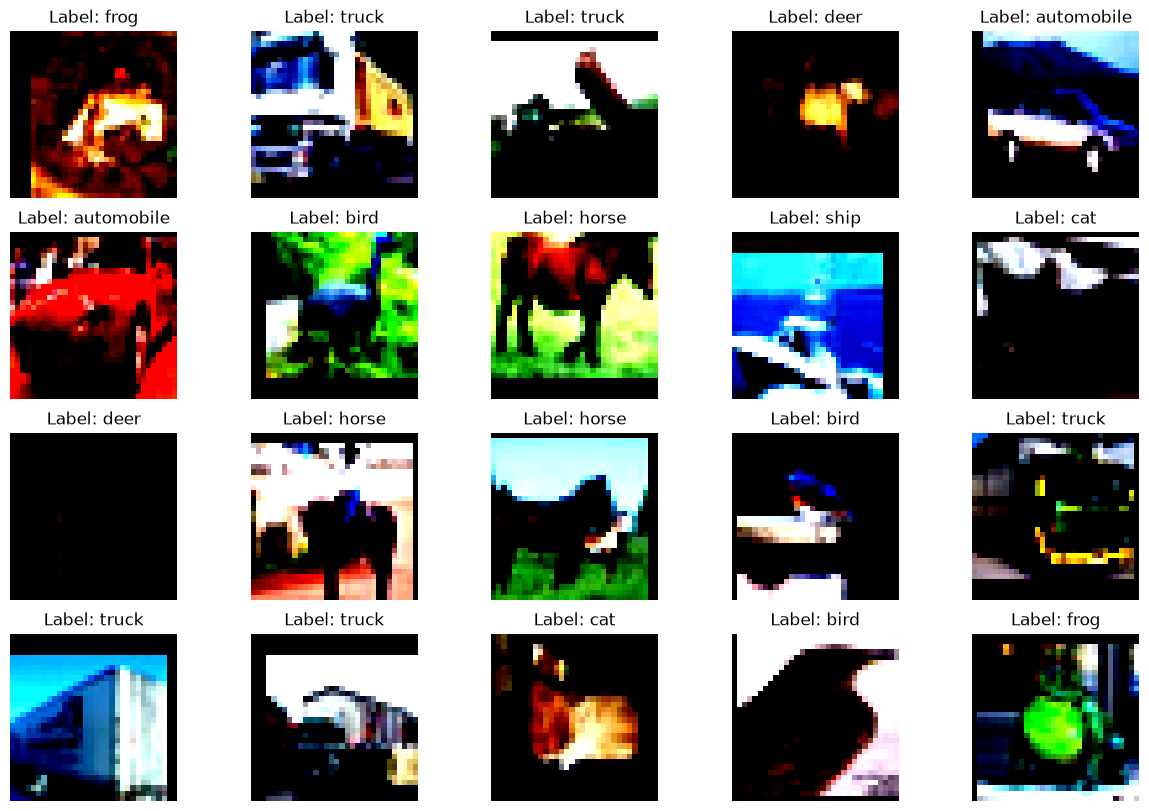

In [14]:
CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

plt.figure(figsize=(15,10))

for index in range(20):
    image, label = train_dataset[index]
    image_rgb = image.permute(1, 2, 0)
    plt.subplot(4,5,index+1), plt.imshow(image_rgb), plt.title(f"Label: {CIFAR10_CLASSES[label]}")
    plt.axis("off");

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).<br>
이 메세지는 RGB 값 범위가 [0.0, 1.0]에서 벗어났기 때문입니다.

정규화를 통해 안정적인 학습에는 도움이 되지만, 시각화를 위해 역정규화가 필요합니다.

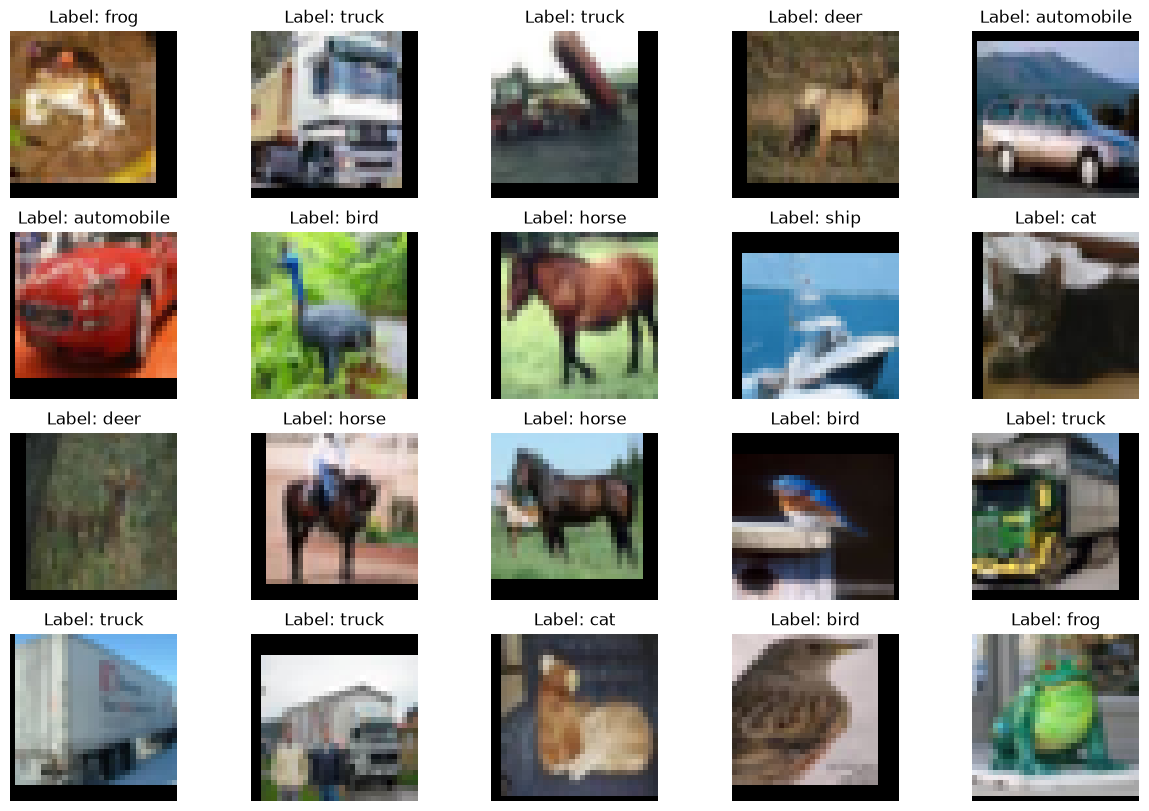

In [15]:
mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
std = torch.tensor(CIFAR10_STD).view(3, 1, 1)

plt.figure(figsize=(15,10))

for index in range(20):
    image, label = train_dataset[index]
    image_denormalized = image * std + mean
    image_rgb = image_denormalized.permute(1, 2, 0).clamp(0, 1)
    plt.subplot(4,5,index+1), plt.imshow(image_rgb), plt.title(f"Label: {CIFAR10_CLASSES[label]}")
    plt.axis("off");

## $7)$ DataLoader 생성

CIFAR-10 데이터는 MNIST보다 이미지 크기도 크며 색상 채널이 존재하기에 Batch 크기를 줄여줍시다.

In [16]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [17]:
images, labels = next(
    iter(train_loader)
)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

images, labels = next(
    iter(test_loader)
)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 32, 32])
Labels shape: torch.Size([32])
Images shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])


## $8)$ CNN 모델 정의

CIFAR-10은 MNIST보다 이미지의 색상, 배경, 객체의 형태와 위치가 훨씬 다양합니다. 따라서 MNIST에서 사용한 단순한 CNN보다 더 많은 Channel과 Convolution Layer를 사용하여 다양한 수준의 특징을 충분히 추출할 필요가 있습니다.

CNN의 앞부분에서는 선, 경계, 색상 변화처럼 비교적 단순한 특징을 추출하고, Layer가 깊어질수록 질감, 사물의 부분적인 형태, 객체 전체의 구조처럼 더 복잡한 특징을 학습합니다. 또한 Channel 수를 점차 증가시키면 각 단계에서 더 다양한 종류의 Feature Map을 생성할 수 있습니다.

```text
64 Channels
→ 비교적 단순한 색상과 경계 특징 추출

128 Channels
→ 질감과 부분적인 형태 추출

256 Channels
→ 객체를 구분하기 위한 복잡한 특징 추출
```
<br>

이번 CIFAR-10 모델에서는 MNIST의 `SimpleCNN`에 없었던 `BatchNorm2d`, `AdaptiveAvgPool2d`, `Dropout`도 추가합니다. 이러한 Layer들은 CIFAR-10에 반드시 필요한 것은 아니지만, 더 깊고 복잡한 CNN을 안정적으로 학습하고 과적합을 완화하는 데 도움을 줍니다.

* `BatchNorm2d`:
  * Convolution Layer의 출력 분포를 조정하여 학습을 안정화
  * 각 Batch의 Feature Map을 정규화
* `AdaptiveAvgPool2d`:
  * 각 Feature Map의 공간 영역을 평균값 하나로 압축
  * 256 × 4 × 4 Feature Map을 256 × 1 × 1로 변환
  * FC Layer에 전달할 Feature 수와 파라미터 수 감소
* `Dropout`:
  * 학습 과정에서 일부 Feature를 무작위로 비활성화
  * 모델이 특정 Feature에 지나치게 의존하는 것을 방지하고 과적합을 완화

<br>CIFAR-10을 분류하기 위한 CNN 구조를 아래와 같이 구성합니다.

<div style="text-align: center;">
  [입력]<br>
  3 × 32 × 32<br>
  ↓<br><br>

  [Conv1-1]<br>
  64 × 32 × 32<br>
  ↓<br>
  [Batch Normalization]<br>
  64 × 32 × 32<br>
  ↓<br>
  [ReLU]<br>
  64 × 32 × 32<br>
  ↓<br>
  [Conv1-2]<br>
  64 × 32 × 32<br>
  ↓<br>
  [Batch Normalization]<br>
  64 × 32 × 32<br>
  ↓<br>
  [ReLU]<br>
  64 × 32 × 32<br>
  ↓<br>
  [Max Pooling]<br>
  64 × 16 × 16<br>
  ↓<br><br>

  [Conv2-1]<br>
  128 × 16 × 16<br>
  ↓<br>
  [Batch Normalization]<br>
  128 × 16 × 16<br>
  ↓<br>
  [ReLU]<br>
  128 × 16 × 16<br>
  ↓<br>
  [Conv2-2]<br>
  128 × 16 × 16<br>
  ↓<br>
  [Batch Normalization]<br>
  128 × 16 × 16<br>
  ↓<br>
  [ReLU]<br>
  128 × 16 × 16<br>
  ↓<br>
  [Max Pooling]<br>
  128 × 8 × 8<br>
  ↓<br><br>

  [Conv3-1]<br>
  256 × 8 × 8<br>
  ↓<br>
  [Batch Normalization]<br>
  256 × 8 × 8<br>
  ↓<br>
  [ReLU]<br>
  256 × 8 × 8<br>
  ↓<br>
  [Conv3-2]<br>
  256 × 8 × 8<br>
  ↓<br>
  [Batch Normalization]<br>
  256 × 8 × 8<br>
  ↓<br>
  [ReLU]<br>
  256 × 8 × 8<br>
  ↓<br>
  [Max Pooling]<br>
  256 × 4 × 4<br>
  ↓<br><br>

  [Global Average Pooling]<br>
  256 × 1 × 1<br>
  ↓<br>
  [Flatten]<br>
  256<br>
  ↓<br>
  [Dropout]<br>
  256<br>
  ↓<br>
  [Fully Connected]<br>
  10
</div>

우선, CNN 구조에서 반복되는 층(Layers)을 재사용하기 위해 하나의 클래스로 만들어줍니다. CIFAR-10의 CNN 구조에서 반복되는 구간은 다음과 같습니다.

<br>
<div style="text-align: center;">
  Convolution → Batch Normalization → ReLU  → Convolution → Batch Normalization → ReLU → Max Pooling
</div>
<br>

In [18]:
class ConvBlock(nn.Module):
    """
    Convolution을 이용해 특징을 추출하고 Max Pooling을 적용하는 재사용 가능한 CNN 블록.

    기본 구조:
    Conv2d → BatchNorm2d → ReLU
    → Conv2d → BatchNorm2d → ReLU
    → MaxPool2d
    """
    
    def __init__(self, in_channels, out_channels):
        super().__init__()

         # Block을 구성할 Layer들을 순서대로 저장
        layers = [

            # 첫 번째 Convolution (특징 추출)
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),

            # 각 출력 채널의 값 분포를 조정하여 학습 안정화
            nn.BatchNorm2d(out_channels),

            # ReLU 활성화 함수
            nn.ReLU(),

            # 두 번째 Convolution (특징 추가적으로 추출)
            nn.Conv2d(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),

            # 두 번째 Convolution의 출력을 정규화
            nn.BatchNorm2d(out_channels),

            # 두 번째 활성화 함수를 적용
            nn.ReLU(),

            # Max Pooling 적용하여 다운스케일
            nn.MaxPool2d(
                kernel_size=2,
                stride=2,
            )
            
        ]

        # 리스트에 저장한 Layer들을 순서대로 실행하는 하나의 Sequential Module로 구성
        self.block = nn.Sequential(*layers)

    # 입력 x를 self.block의 Layer에 순서대로 전달
    def forward(self, x):
        return self.block(x)

위에서 정의한 CNN 블록을 사용하여 CIFAR-10 분류 모델을 정의합니다.

In [19]:
class CIFAR10CNN(nn.Module):
    """
    CIFAR-10의 32x32 RGB 이미지를 10개 클래스로 분류하는 CNN 모델.

    전체 구조:
    ConvBlock 1
    → ConvBlock 2
    → ConvBlock 3
    → Global Average Pooling
    → Dropout
    → Linear
    """

    def __init__(self):
        super().__init__()

        # 이미지에서 특징을 추출하는 부분 (ConvBlock 1 → ConvBlock 2 → ConvBlock 3)
        self.features = nn.Sequential(
            ConvBlock( in_channels=3  , out_channels=64 , ), # 출력: [Batch, 64, 16, 16]
            ConvBlock( in_channels=64 , out_channels=128, ), # 출력: [Batch, 128, 8, 8]
            ConvBlock( in_channels=128, out_channels=256, ), # 출력: [Batch, 256, 4, 4]
        )

        # 각 4×4 Feature Map의 평균을 계산하여 공간 크기를 1×1로 압축
        self.global_average_pool = (    # 출력: [Batch, 256, 1, 1]
            nn.AdaptiveAvgPool2d( output_size=(1, 1) )
        )

        # 추출된 특징을 이용해 최종 클래스를 예측
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),         
            nn.Linear(                 
                in_features=256,        # 출력: 256
                out_features=10,        # 출력: 10
            ),
        )

    # 입력 이미지: [Batch, 3, 32, 32]
    def forward(self, x):
                                            
        x = self.features(x)                # 세 개의 ConvBlock을 통과하며 특징을 추출  # 출력: [Batch, 256, 4, 4]

        x = self.global_average_pool(x)     # 각 채널의 4×4 값을 평균내어 1×1로 압축    # 출력: [Batch, 256, 1, 1]

        x = torch.flatten(x, start_dim=1)   # Tensor를 2차원으로 펼침                 # [Batch, 256, 1, 1] → [Batch, 256]

        logits = self.classifier(x)         # 각 클래스에 대한 점수인 Logit을 계산      # 출력: [Batch, 10]

        return logits

모델을 정의했으니, 시각화하여 확인해봅시다.

In [21]:
def visualize_model(model, input_shape):
    model_img = visualtorch.render(
        model,
        input_shape=input_shape,
        style="flow",
        legend=True,
        scale_xy=4,
        min_xy=2,
        max_xy=500,
        )

    return model_img

In [26]:
# import sys
# !"{sys.executable}" -m ensurepip --upgrade
# !"{sys.executable}" -m pip install --upgrade pip
# !"{sys.executable}" -m pip install visualtorch


Looking in links: c:\Users\actua\AppData\Local\Temp\tmp_dkbyqq8
Processing c:\users\actua\appdata\local\temp\tmp_dkbyqq8\pip-25.0.1-py3-none-any.whl


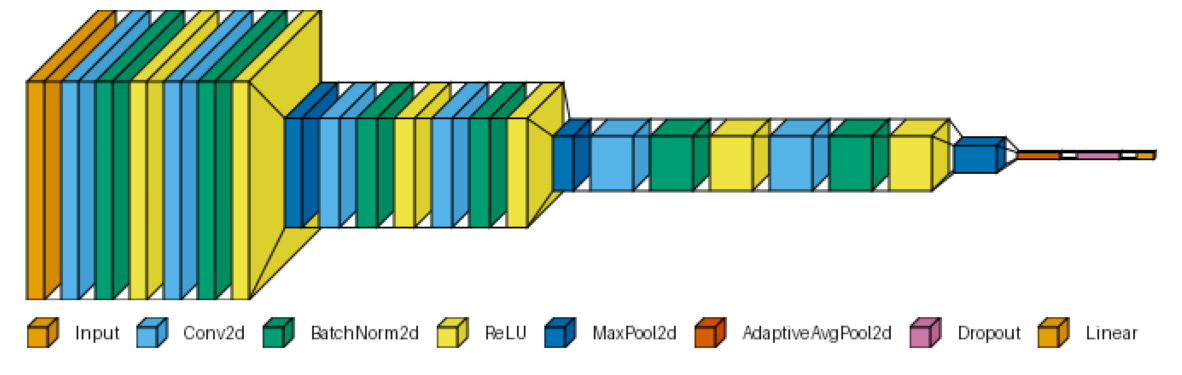

In [29]:
import visualtorch

model_struct = visualize_model(CIFAR10CNN(), (1,3,32,32))

plt.figure(figsize=(15,6))
plt.imshow(model_struct)
plt.axis("off");

## $9)$ 모델 생성 및 GPU 지정

이번 이미지 분류 작업은 학습할 파라미터 수가 매우 많아 오직 GPU에서만 진행합니다.

먼저 모델을 생성하고 GPU로 옮겨주겠습니다.

In [30]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU를 사용할 수 없습니다."
    )

device = torch.device("cuda")
model = CIFAR10CNN().to(device)

print("Device:", device)
print(model)

Device: cuda
CIFAR10CNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, moment

모델이 학습할 파라미터 수를 확인해봅시다.

In [31]:
parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", parameter_count)
print("Trainable parameters:", trainable_parameter_count)

Total parameters: 1148874
Trainable parameters: 1148874


## $10)$ 손실 함수 및 Optimizer 설정

CIFAR-10 학습에서는 MNIST 학습과 동일한 손실 함수와 Optimizer를 사용합니다.

In [32]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
)

## $11)$ GPU Warm-up

GPU는 첫 연산을 실행할 때 CUDA Context 생성, cuDNN 초기화, 메모리 할당 등의 준비 작업을 수행합니다. 이 초기화 시간이 학습 시간에 포함되면 첫 번째 측정 결과가 실제보다 느리게 나타날 수 있습니다.

따라서 실제 학습 시간을 측정하기 전에 동일한 형태의 연산을 몇 번 미리 실행하여 GPU를 준비합니다. 이를 GPU Warm-up이라고 합니다.

In [33]:
warmup_input = torch.zeros(64, 3, 32, 32, device=device)

model.eval()

with torch.no_grad():
    for _ in range(3):
        _ = model(warmup_input)

torch.cuda.synchronize()

## $12)$ CNN 모델 학습

앞선 MNIST 실습에서 정의한 `train_one_epoch()`와 `evaluate()` 함수를 사용하여 CIFAR-10 데이터셋을 학습해봅시다.

In [34]:
# TODO: CUDA GPU 장치에서 CIFAR-10 데이터셋을 학습과 평가
# TODO: 각 Epoch 및 전체 학습 시간을 출력

EPOCHS = 5

# 학습 기록 저장 공간 준비
train_loss_history = []
train_accuracy_history = []
test_loss_history = []
test_accuracy_history = []

# 전체 학습 시간 측정 시작
torch.cuda.synchronize()
training_start_time = time.perf_counter()

# TODO: 5번의 Epoch 동안 학습 및 평가 진행
# for epoch in range(EPOCHS):
#     ...

#     print(
#         f"Epoch {epoch + 1}/{EPOCHS} | "
#         f"Train loss: {train_loss:.4f} | "
#         f"Train accuracy: "
#         f"{train_accuracy * 100:.2f}% | "
#         f"Test loss: {test_loss:.4f} | "
#         f"Test accuracy: "
#         f"{test_accuracy * 100:.2f}% | "
#         f"Time: {epoch_time:.2f}s"
#     )

# TODO: 전체 학습 시간 계산 및 출력
# print(f"Total GPU training time: {total_training_time:.2f}s")

for epoch in range(EPOCHS):
    # Epoch 시작 시간 저장
    torch.cuda.synchronize()
    epoch_start_time = time.perf_counter()

    # 모델 학습
    train_loss, train_accuracy = train_one_epoch( model, train_loader, criterion, optimizer, device, )

    # 모델 평가
    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        criterion,
        device,
    )

    # Epoch 소요 시간 계산
    torch.cuda.synchronize()
    epoch_time = (time.perf_counter() - epoch_start_time)

    # 결과 저장 (학습 & 평가)
    train_loss_history.append(train_loss)
    train_accuracy_history.append(train_accuracy)
    test_loss_history.append(test_loss)
    test_accuracy_history.append(test_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: "
        f"{train_accuracy * 100:.2f}% | "
        f"Test loss: {test_loss:.4f} | "
        f"Test accuracy: "
        f"{test_accuracy * 100:.2f}% | "
        f"Time: {epoch_time:.2f}s"
    )

# 전체 학습 시간 계산 및 출력
torch.cuda.synchronize()
total_training_time = time.perf_counter() - training_start_time
print(f"Total GPU training time: {total_training_time:.2f}s")

Epoch 1/5 | Train loss: 1.3072 | Train accuracy: 52.29% | Test loss: 1.1592 | Test accuracy: 59.48% | Time: 107.85s
Epoch 2/5 | Train loss: 0.9088 | Train accuracy: 67.93% | Test loss: 0.8133 | Test accuracy: 71.41% | Time: 120.67s
Epoch 3/5 | Train loss: 0.7305 | Train accuracy: 74.65% | Test loss: 0.7788 | Test accuracy: 73.56% | Time: 120.79s
Epoch 4/5 | Train loss: 0.6334 | Train accuracy: 78.27% | Test loss: 0.6093 | Test accuracy: 79.89% | Time: 121.09s
Epoch 5/5 | Train loss: 0.5628 | Train accuracy: 80.88% | Test loss: 0.5728 | Test accuracy: 80.64% | Time: 120.86s
Total GPU training time: 591.26s


학습이 완료되었다면, 테스트 데이터를 사용해 모델 성능을 평가해봅시다.

True label: 3
Predicted label: 3
Confidence: 0.9813599586486816


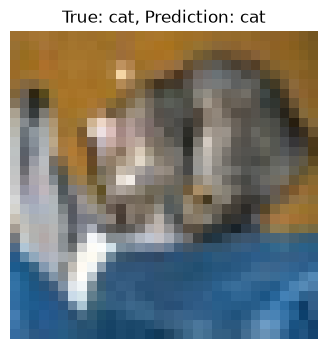

In [35]:
# 학습된 모델로 이미지 하나 테스트
image, true_label = test_dataset[0]          # 테스트할 이미지(image)와 정답(label)
input_batch = image.unsqueeze(0).to(device)  # Batch 차원 추가(unsqueeze)하여 입력 Batch로 저장 (이미지 1장)

# 모델을 평가 모드(evaluation mode)로 변경
model.eval()

# Gradient 계산을 비활성화 (파라미터 수정 비활성화)
with torch.no_grad():
    logits = model(input_batch)                           # 학습된 모델의 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
    probabilities = torch.softmax(logits, dim=1)          # 원시 점수에 softmax 함수 적용 (클래스별 확률 계산)
    predicted_label = probabilities.argmax(dim=1).item()  # 정답 예측

# 결과 출력 (정답, 예측, confidence)
print("True label:", true_label)
print("Predicted label:", predicted_label)
print("Confidence:", probabilities[0, predicted_label].item())

# 결과 이미지 출력
CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
std = torch.tensor(CIFAR10_STD).view(3, 1, 1)

image_denormalized = image.squeeze(0) * std + mean
image_rgb = image_denormalized.permute(1, 2, 0).clamp(0, 1)
image_rgb_cpu = image_rgb.cpu()

plt.figure(figsize=(4,4))
plt.imshow(image_rgb_cpu)
plt.title(f"True: {CIFAR10_CLASSES[true_label]}, " f"Prediction: {CIFAR10_CLASSES[predicted_label]}")
plt.axis("off")
plt.show()

학습이 완료된 모델로 여러 장의 이미지를 분류해봅시다.

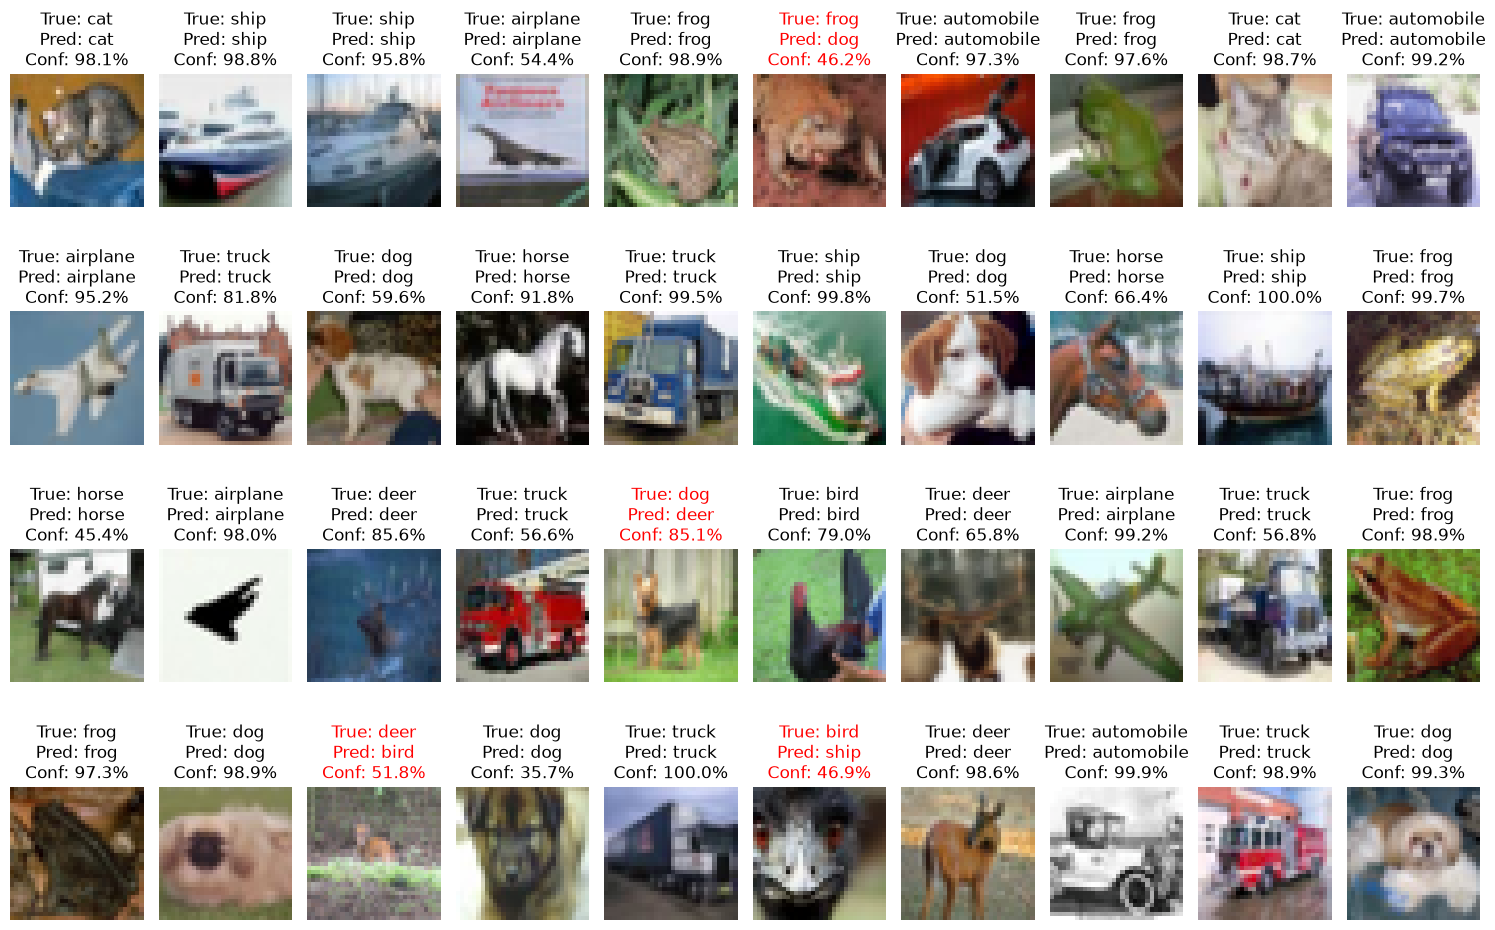

In [36]:
plt.figure(figsize=(15,10))

num_images = 40

model.eval()

with torch.no_grad():
    for i in range(num_images):
        image, true_label = test_dataset[i]
        input_batch = image.unsqueeze(0).to(device)

        logits = model(input_batch)
        probabilities = torch.softmax(logits, dim=1)
        predicted_label = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, predicted_label].item()

        image_denormalized = image.squeeze(0) * std + mean
        image_rgb = image_denormalized.permute(1, 2, 0).clamp(0, 1)
        image_rgb_cpu = image_rgb.cpu()

        title_color = "red" if predicted_label != true_label else "black"

        plt.subplot(4, 10, i+1)
        plt.imshow(image_rgb_cpu)
        plt.title(
            f"True: {CIFAR10_CLASSES[true_label]}\n"
            f"Pred: {CIFAR10_CLASSES[predicted_label]}\n"
            f"Conf: {confidence*100:.1f}%",
            color=title_color
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

학습 난이도가 높은 CIFAR-10 데이터셋은 현재 설정한 Epoch로는 충분히 학습되지 않아 이미지 분류에 실패한 데이터가 확인됩니다.

## $13)$ CNN 모델 학습 지표 시각화

학습이 진행됨에 따라 Epoch별 학습 및 평가의 Loss와 Accuracy를 그래프로 나타내봅시다.

Loss 그래프:

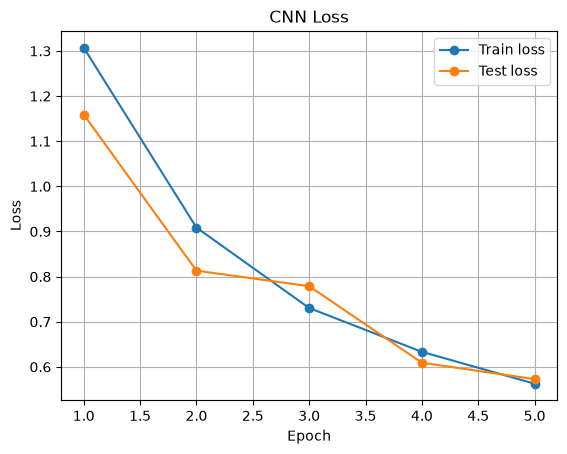

In [37]:
epoch_axis = range(1, EPOCHS + 1)

plt.plot(
    epoch_axis,
    train_loss_history,
    marker="o",
    label="Train loss",
)

plt.plot(
    epoch_axis,
    test_loss_history,
    marker="o",
    label="Test loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.grid()
plt.legend()
plt.show()

Accuracy 그래프:

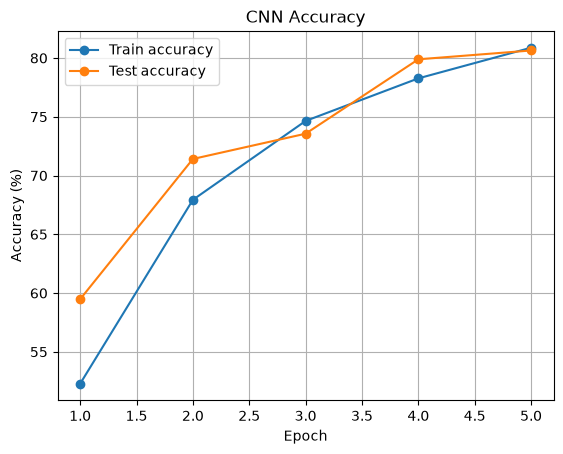

In [38]:
plt.plot(
    epoch_axis,
    np.array(train_accuracy_history) * 100,
    marker="o",
    label="Train accuracy",
)

plt.plot(
    epoch_axis,
    np.array(test_accuracy_history) * 100,
    marker="o",
    label="Test accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Accuracy")
plt.grid()
plt.legend()
plt.show()

## $14)$ 모델 저장 및 불러오기

CIFAR-10과 같이 학습에 오랜 시간이 걸리는 데이터셋은 모델을 학습시킨 뒤 저장하는 것이 중요합니다.

모델 저장:

In [40]:
save_data = {
    "model_name": "CIFAR10CNN",
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "test_accuracy": test_accuracy_history[-1],
    "epochs": EPOCHS,
    "class_names": CIFAR10_CLASSES,
    "mean": CIFAR10_MEAN,
    "std": CIFAR10_STD,
}

torch.save(
    save_data,
    "src/models/CIFAR10/CIFAR10_CNN.pth",
)

모델 불러오기:

In [41]:
loaded_model = CIFAR10CNN()

state_dict = torch.load(
    "src/models/CIFAR10/CIFAR10_CNN.pth",
    map_location="cpu",
    weights_only=True,
)

loaded_model.load_state_dict(state_dict["model_state_dict"])
loaded_model.to(device)
loaded_model.eval()

CIFAR10CNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affin

모델이 제대로 불러와졌는지 확인해봅시다.

In [42]:
    # "model_name": "CIFAR10CNN",
    # "model_state_dict": model.state_dict(),
    # "optimizer_state_dict": optimizer.state_dict(),
    # "test_accuracy": test_accuracy_history[-1],
    # "epochs": EPOCHS,
    # "class_names": CIFAR10_CLASSES,
    # "mean": CIFAR10_MEAN,
    # "std": CIFAR10_STD,
print("모델 이름:", state_dict["model_name"])
print("Epoch 체크포인트:", state_dict["epochs"])
print(f"마지막 테스트 정확도: {state_dict['test_accuracy'] * 100:.2f}%")

모델 이름: CIFAR10CNN
Epoch 체크포인트: 5
마지막 테스트 정확도: 80.64%


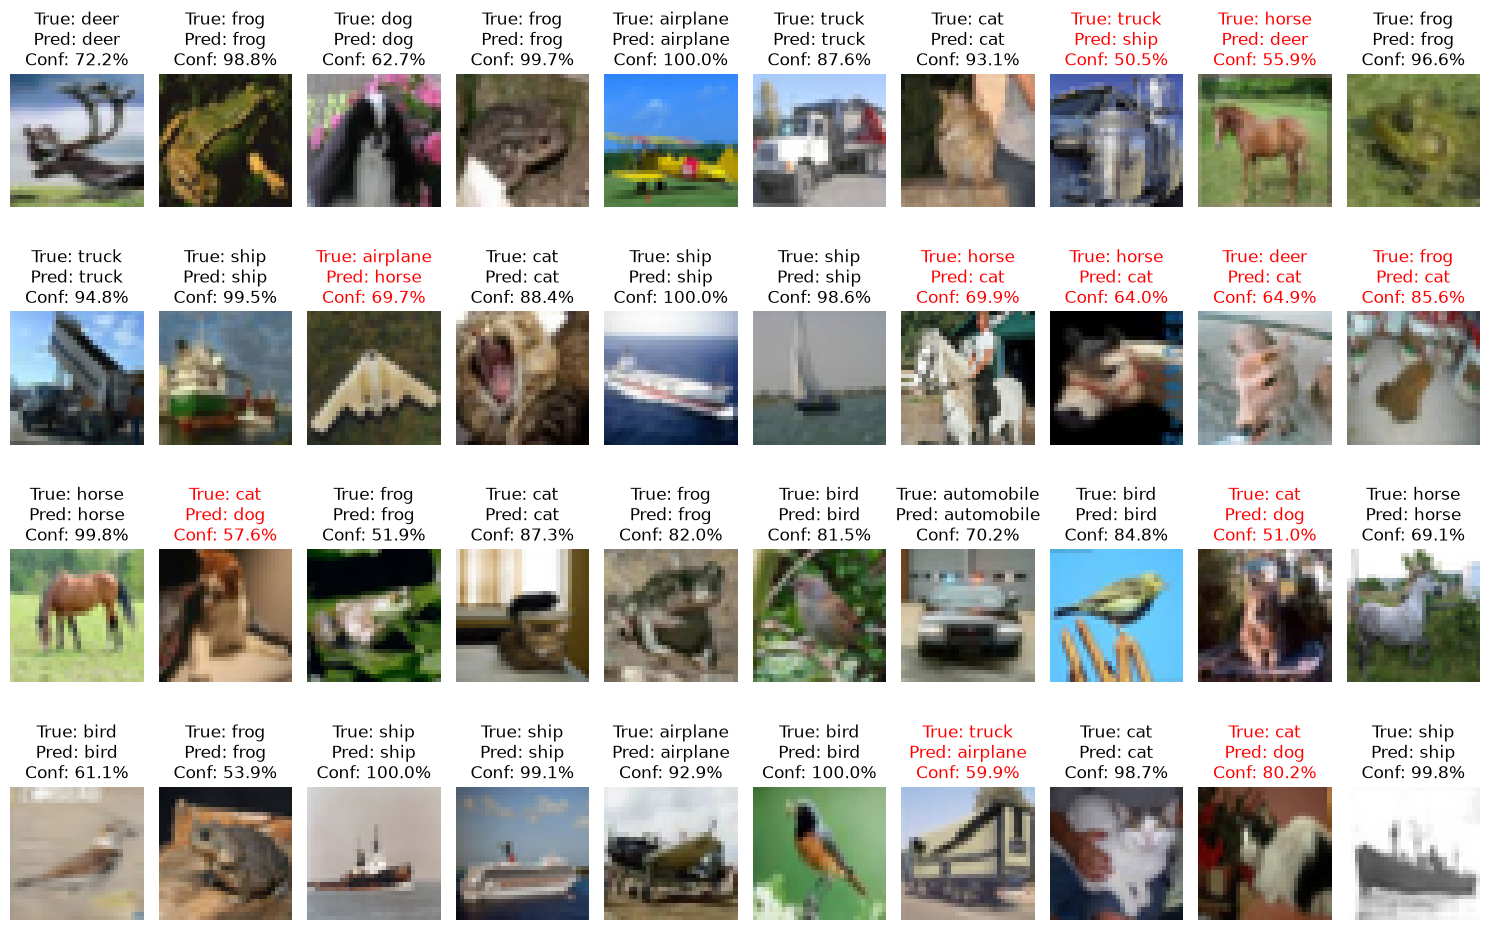

In [43]:
plt.figure(figsize=(15,10))

num_images = 40

loaded_model.eval()

with torch.no_grad():
    for i in range(num_images):
        image, true_label = test_dataset[i+40]
        input_batch = image.unsqueeze(0).to(device)

        logits = loaded_model(input_batch)
        probabilities = torch.softmax(logits, dim=1)
        predicted_label = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, predicted_label].item()

        image_denormalized = image.squeeze(0) * std + mean
        image_rgb = image_denormalized.permute(1, 2, 0).clamp(0, 1)
        image_rgb_cpu = image_rgb.cpu()

        title_color = "red" if predicted_label != true_label else "black"

        plt.subplot(4, 10, i+1)
        plt.imshow(image_rgb_cpu)
        plt.title(
            f"True: {CIFAR10_CLASSES[true_label]}\n"
            f"Pred: {CIFAR10_CLASSES[predicted_label]}\n"
            f"Conf: {confidence*100:.1f}%",
            color=title_color
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

GPU 가속을 활용한 CIFAR-10 이미지 분류 결과를 확인하는 것을 마지막으로 **"딥러닝 기초 및 GPU 가속"** 섹션을 마치겠습니다.

지금까지 배운 내용을 바탕으로, 이어지는 섹션 4에서는 다음 단계의 내용을 살펴보겠습니다.

---
---

<br><br><div style="text-align: right; color: gray; font-style: italic;">
© 2026, 김규래 (Kyu Rae Kim), All rights reserved.&emsp;<br><br>
This material is provided solely for the intended instructional purpose.&emsp;<br>
Redistribution, reproduction, modification, adaptation, or reuse of this material in any form without prior written permission from the copyright holder is prohibited.&emsp;
</div>